In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [19]:
df = pd.read_parquet("nyiso_dataset", engine="pyarrow")

In [20]:
#need to double check zone coords
zone_coords = {
    "CAPITL": (42.65, -73.75),
    "CENTRL": (43.05, -76.15),
    "DUNWOD": (41.01, -73.78),
    "GENESE": (43.17, -77.61),
    "HUD VL": (41.70, -73.93),
    "MHK VL": (42.10, -75.91),
    "MILLWD": (41.13, -73.78),
    "N.Y.C.": (40.71, -74.01),
    "NORTH": (44.70, -73.45),
    "WEST": (42.89, -78.87)
}

In [21]:
df

,Time Stamp,Time Zone,Name,PTID,Load,year,month
0,2001-05-28 00:00:00,EDT,CAPITL,61757.0,894.0000,2001,5
1,2001-05-28 00:00:00,EDT,CENTRL,61754.0,1346.0000,2001,5
2,2001-05-28 00:00:00,EDT,DUNWOD,61760.0,415.0000,2001,5
3,2001-05-28 00:00:00,EDT,GENESE,61753.0,746.0000,2001,5
4,2001-05-28 00:00:00,EDT,HUD VL,61758.0,978.0000,2001,5
...,...,...,...,...,...,...,...
29327978,2025-10-03 23:55:00,EDT,MHK VL,61756.0,671.4786,2025,10
29327979,2025-10-03 23:55:00,EDT,MILLWD,61759.0,206.7461,2025,10
29327980,2025-10-03 23:55:00,EDT,N.Y.C.,61761.0,4669.4595,2025,10
29327981,2025-10-03 23:55:00,EDT,NORTH,61755.0,567.2412,2025,10


In [22]:
df_total_load = df.groupby("Time Stamp", as_index=False)["Load"].sum()
df_total_load.rename(columns={"Time Stamp": "Time"}, inplace=True)


In [23]:
df_total_load

,Time,Load
0,2001-05-26 00:00:00,13859.0000
1,2001-05-26 00:00:50,13761.0000
2,2001-05-26 00:05:20,13718.0000
3,2001-05-26 00:06:50,13622.0000
4,2001-05-26 00:11:50,13551.0000
...,...,...
2713135,2025-10-08 12:55:00,15401.3201
2713136,2025-10-08 13:00:00,15400.6558
2713137,2025-10-08 13:05:00,15490.6380
2713138,2025-10-08 13:10:00,15456.0476


In [24]:
df_total_load = df_total_load.tail(200000)
df_total_load


,Time,Load
2513140,2023-11-27 08:40:00,17351.8851
2513141,2023-11-27 08:45:00,17321.7836
2513142,2023-11-27 08:50:00,17304.7009
2513143,2023-11-27 08:55:00,17276.3627
2513144,2023-11-27 09:00:00,17293.1005
...,...,...
2713135,2025-10-08 12:55:00,15401.3201
2713136,2025-10-08 13:00:00,15400.6558
2713137,2025-10-08 13:05:00,15490.6380
2713138,2025-10-08 13:10:00,15456.0476


In [25]:
training = df_total_load[:int(len(df_total_load)*0.8)]["Load"]
testing = df_total_load[int(len(df_total_load)*0.8):]["Load"]

In [26]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(pd.DataFrame(training))
test_scaled = scaler.transform(pd.DataFrame(testing))

In [27]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:i + time_steps]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_train, y_train = create_dataset(train_scaled, train_scaled, TIME_STEPS)
X_test, y_test = create_dataset(test_scaled, test_scaled, TIME_STEPS)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(159990, 10, 1) (159990, 1)
(39990, 10, 1) (39990, 1)


In [28]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.01)

svr.fit(X_train.reshape(X_train.shape[0], -1), y_train)

# Make predictions
train_pred = svr.predict(X_train.reshape(X_train.shape[0], -1))
test_pred = svr.predict(X_test.reshape(X_test.shape[0], -1))

# Inverse scaling
train_pred_inv = scaler.inverse_transform(train_pred.reshape(-1, 1))
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


C:\Users\sarah\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
from sklearn.metrics import mean_absolute_error
# Evaluate the model
mae_train = mean_absolute_error(y_train_inv, train_pred_inv)
mae_test = mean_absolute_error(y_test_inv, test_pred_inv)
print("Mean Absolute Error on Training Data:", mae_train)
print("Mean Absolute Error on Testing Data:", mae_test)

Mean Absolute Error on Training Data: 38.45759652463631
Mean Absolute Error on Testing Data: 40.06559313099357


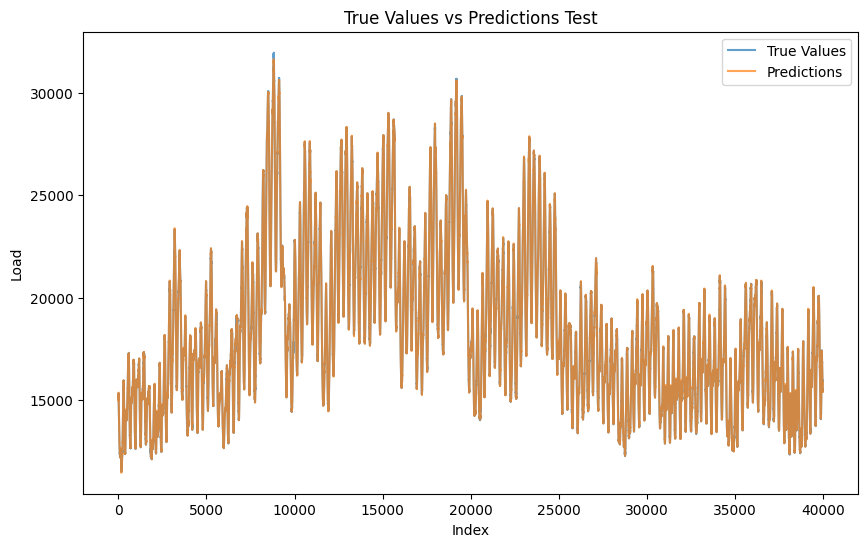

In [30]:
import matplotlib.pyplot as plt

# Line plot of the truth and the predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, label="True Values", alpha=0.7)
plt.plot(test_pred_inv, label="Predictions", alpha=0.7)
plt.legend()
plt.title("True Values vs Predictions Test")
plt.xlabel("Index")
plt.ylabel("Load")
plt.show()

In [31]:
# from datetime import datetime
# import matplotlib.pyplot as plt
# import meteostat
# from meteostat import Point, Daily, Hourly

# start = datetime(2018, 1, 1, 0, 0)
# end = datetime(2018, 1, 1, 12, 0)

# # Create Point for Vancouver, BC
# vancouver = Point(42.65, -73.75)

# # Get daily data for 2018
# data = Hourly(vancouver, start, end)
# data = data.fetch()

# # Plot line chart including average, minimum and maximum temperature
# data